### 3 - Construir una aproximación del frente de Pareto barriendo el vector de pesos y filtrando la soluciones no dominadas.

* Minimizar $f_1(x) = -10 exp (-0.2 \sqrt{x_1^2 + x_2^2})$
* Minimizar $f_2(x) = \sum_{i=1}^{2} [ \lvert x_i \rvert^{0.8} + 5\sin{x_i^3} ] $
* $-5 \leq x_i \leq 5$, $i=1, 2$ 

In [37]:
import numpy as np

In [38]:
# mesh
x1 = np.linspace(-5, 5, 1500)
x2 = np.linspace(-5, 5, 1500)
X1, X2 = np.meshgrid(x1, x2)

f1 = -10 * np.exp(-0.2 * np.sqrt(X1**2 + X2**2))

f21 = np.abs(X1)**0.8 + 5 * np.sin(X1**3)
f22 = np.abs(X2)**0.8 + 5 * np.sin(X2**3)
f2 = f21 + f22

In [39]:
pesos = np.linspace(0, 1, 1000)

puntos_f1 = []
puntos_f2 = []

for w in pesos:
    # por suma ponderada
    F = w * f1 + (1 - w) * f2
    
    # posición donde la combinacion lineal alcanza su minimo
    idx_min = np.unravel_index(np.argmin(F), F.shape)

    puntos_f1.append(f1[idx_min])
    puntos_f2.append(f2[idx_min])

In [40]:
pareto_f1 = []
pareto_f2 = []

n = len(puntos_f1)
for i in range(n):
    es_dominada = False
    for j in range(n):
        if i != j:
            # j domina a i si es igual o mejor en ambos objetivos y estrictamente mejor en al menos uno
            if (puntos_f1[j] <= puntos_f1[i] and puntos_f2[j] <= puntos_f2[i]) and \
               (puntos_f1[j] < puntos_f1[i] or puntos_f2[j] < puntos_f2[i]):
                es_dominada = True
                break
    
    if not es_dominada:
        pareto_f1.append(puntos_f1[i])
        pareto_f2.append(puntos_f2[i])

In [41]:
import matplotlib.pyplot as plt

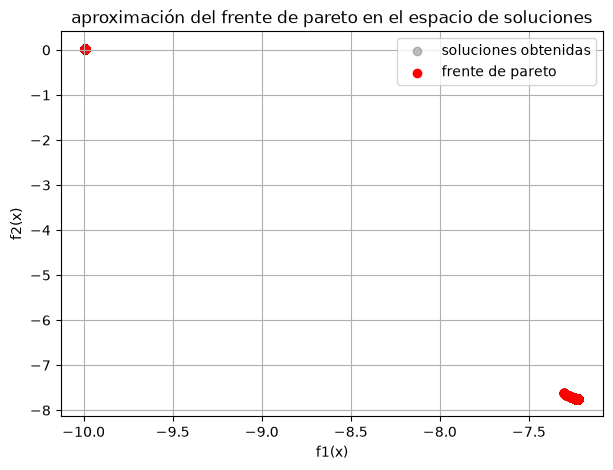

In [42]:
plt.figure(figsize=(7, 5))
plt.scatter(puntos_f1, puntos_f2, color='gray', alpha=0.5, label='soluciones obtenidas')
plt.scatter(pareto_f1, pareto_f2, color='red', label='frente de pareto')
plt.xlabel('f1(x)')
plt.ylabel('f2(x)')
plt.title('aproximación del frente de pareto en el espacio de soluciones')
plt.legend()
plt.grid(True)
plt.show()